# Exercise 04 — Recurrent Neural Networks

Last week you averaged word vectors into a single sentence vector — and saw that this throws away **word order** entirely. This week you use models that read a text **one token at a time** and carry a hidden state along the way: the vanilla **RNN**, the **LSTM** and the **GRU**. You train all three to classify news articles and compare them.

## What you will do
1. **Explore the data** — the AG News dataset: how big it is, how long the articles are, how the labels are distributed.
2. **From text to tensors** — tokenize the articles with a pre-trained tokenizer and wrap them in `DataLoader`s.
3. **Build an RNN classifier** — embedding → recurrent layer → linear layer.
4. **Train and evaluate it** — complete the training loop and measure per-class and macro F1.
5. **LSTM and GRU** — swap the recurrent layer, retrain, and compare the three models.
6. **Multiple-choice questions** — to check your understanding.

## How to work through it
- Run the cells **in order** and fill in **every `# TODO`**.
- Tasks are numbered (**1.1**, **1.2**, …). Tasks that say *Your answer here* want a short written answer, not code.
- Most implementation tasks are followed by a **✅ Check** cell that verifies your work automatically. Run it and make sure it passes before you move on.

> **Heads up — this notebook downloads data and trains three models.** The AG News dataset (~30 MB) and the tokenizer are downloaded in the first cells. Each model trains for 3 epochs on 120k articles, which takes roughly 3–6 minutes per model on a CPU. Start each training cell as soon as it is ready and read ahead while it runs.

Please update your environment before running this notebook using <code onclick="navigator.clipboard.writeText(this.textContent)" style="cursor:pointer" title="Click to copy">uv sync</code> — this week adds the `transformers` library.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

torch.manual_seed(0)

# Use the GPU if there is one; a CPU is enough for this notebook.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


## 1. The data: AG News

We use the **AG News** topic-classification dataset. It was built from a corpus of more than one million news articles by keeping the four largest categories: **World**, **Sports**, **Business** and **Sci/Tech**. Every article is a short title plus description, labelled with one of the four topics.

Each example looks like this:

```
{"label": 3,
 "text": "New iPad released Just like every other September, this one is no different. Apple is planning to release a bigger, heavier, fatter iPad that..."}
```

The dataset comes from the Hugging Face Hub, via the `datasets` library you already used last week. The first call downloads it (~30 MB); after that it is cached on disk.

*Xiang Zhang, Junbo Zhao, Yann LeCun. 2015. Character-level Convolutional Networks for Text Classification. NeurIPS 2015.*

In [2]:
dataset = load_dataset("fancyzhx/ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

# The human-readable name of each label id
LABEL_NAMES = train_data.features["label"].names

print(dataset)
print("Labels:", LABEL_NAMES)

print("\nA few training examples:")
for row in train_data.select(range(3)):
    print(f"  [{LABEL_NAMES[row['label']]:<8}] {row['text'][:100]}...")

README.md: 0.00B [00:00, ?B/s]

c:\Users\rasmu\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rasmu\.cache\huggingface\hub\datasets--fancyzhx--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Labels: ['World', 'Sports', 'Business', 'Sci/Tech']

A few training examples:
  [Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...
  [Business] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...
  [Business] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about th...


### Exploring the data

Before building anything, look at the data.

**1.1 Fill in the four blanks below.**

Hints:
- `len(train_data)` gives the number of rows; `train_data["text"]` gives the whole column as a plain Python list.
- Count the words of an article with `len(text.split())` — a rough count, but good enough to get a feel for the length.
- `Counter(train_data["label"])` counts how often each label id occurs.

In [20]:
n_train = len(train_data)       # TODO: number of training articles
n_test = len(test_data)        # TODO: number of test articles
avg = []

for data in train_data["text"]:
                avg.append(len(data.split())) # TODO: average number of words per training article
avg_words = np.mean(avg)
label_counts = Counter(train_data["label"])  # TODO: number of training articles per label id  (hint: Counter)

print(f"Training articles : {n_train:,}")
print(f"Test articles     : {n_test:,}")
print(f"Average length    : {avg_words:.1f} words")
print("Label distribution:")
for label, count in sorted(label_counts.items()):
    print(f"   {label} = {LABEL_NAMES[label]:<9} {count:,}")

Training articles : 120,000
Test articles     : 7,600
Average length    : 37.8 words
Label distribution:
   0 = World     30,000
   1 = Sports    30,000
   2 = Business  30,000
   3 = Sci/Tech  30,000


In [21]:
# ✅ Check your numbers
assert n_train == 120_000, f"expected 120,000 training articles, got {n_train}"
assert n_test == 7_600, f"expected 7,600 test articles, got {n_test}"
assert 30 < avg_words < 50, f"an article has a few dozen words on average, you got {avg_words}"
assert sorted(label_counts) == [0, 1, 2, 3], "there should be exactly four label ids, 0-3"
assert all(count == 30_000 for count in label_counts.values()), "every class has exactly 30,000 training articles"
print("Looks good ✅")

Looks good ✅


**1.2 The dataset is perfectly balanced. Imagine it were not — say 90% of all articles were *Sports*.** Why would plain accuracy be a misleading way to evaluate a classifier on such data, and what does **macro-F1** (the metric we use below) do differently?

---

It would be heavily skewed towards the sports articles and the model would have significantly less training data for the three other categories.

---

## 2. From text to tensors

A neural network cannot read strings. We need to **tokenize** every article — split it into tokens and map each token to an integer id — so that we can look those ids up in an embedding matrix.

Instead of building a vocabulary ourselves, we borrow the **pre-trained tokenizer of BERT** (`bert-base-uncased`) from the `transformers` library. It is a *subword* tokenizer: common words stay whole, rare words are split into pieces (`##ing`, `##ly`, …), so it never meets a word it cannot handle. A few things to know:

- Its vocabulary has **30,522** entries — this will be the size of our embedding matrix.
- Everything is **lowercased**.
- It adds two special tokens: `[CLS]` at the start and `[SEP]` at the end.
- The padding token `[PAD]` has id **0**.

We only use the tokenizer this week. Next week you will meet the model it belongs to.

In [22]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

example = train_data[0]["text"]
encoded = tokenizer(example)

print("Text   :", example)
print("Tokens :", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("IDs    :", encoded["input_ids"])

print(f"\nVocabulary size: {tokenizer.vocab_size:,}")
print(f"Padding token  : {tokenizer.pad_token!r} with id {tokenizer.pad_token_id}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\rasmu\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rasmu\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text   : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Tokens : ['[CLS]', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-', 'short', '-', 'sellers', ',', 'wall', 'street', "'", 's', 'd', '##wind', '##ling', '\\', 'band', 'of', 'ultra', '-', 'cy', '##nic', '##s', ',', 'are', 'seeing', 'green', 'again', '.', '[SEP]']
IDs    : [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102]

Vocabulary size: 30,522
Padding token  : '[PAD]' with id 0


### Fixed-length sequences

The example above has whatever length it happens to have, but to process articles in **mini-batches** we need every sequence in a batch to have the **same length**. The standard fix:

- articles that are **too long** are **truncated**,
- articles that are **too short** are **padded** with `[PAD]` tokens.

We use a fixed length of `MAX_LEN = 50` tokens.

One detail matters for recurrent models: **on which side to pad**. By default the tokenizer pads on the *right*, so a short article ends in a run of `[PAD]` tokens — and our classifier will read the hidden state after the *last* position (Part 3). We therefore tell the tokenizer to pad on the **left**, so that the last position is always a real token. You will think about *why* this matters in 3.3.

**2.1 Complete `encode` so that every article is turned into exactly `MAX_LEN` token ids.**

Hints:
- The tokenizer does all of it for you if you pass the right arguments: `padding="max_length"`, `truncation=True` and `max_length=MAX_LEN`.
- `dataset.map(encode, batched=True)` hands `encode` a **batch** of rows as a dict of lists, so `batch["text"]` is a list of strings — the tokenizer accepts a list directly.
- `map` adds the tokenizer's output (`input_ids`, `attention_mask`, …) as new columns.

In [26]:
MAX_LEN = 50
tokenizer.padding_side = "left"  # pad at the start, so the last position is always a real token

def encode(batch):
    # TODO: tokenize batch["text"] so that every sequence has exactly MAX_LEN token ids
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LEN)

encoded_dataset = dataset.map(encode, batched=True)
print(encoded_dataset)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


In [27]:
# ✅ Check your encoding
assert "input_ids" in encoded_dataset["train"].column_names, "map should have added an 'input_ids' column"

sample_ids = encoded_dataset["train"][:200]["input_ids"]
assert all(len(ids) == MAX_LEN for ids in sample_ids), "every sequence must have exactly MAX_LEN ids — did you set padding and truncation?"

shortest = max(sample_ids, key=lambda ids: ids.count(tokenizer.pad_token_id))
print("A short article, padded:")
print(tokenizer.convert_ids_to_tokens(shortest))
assert shortest[0] == tokenizer.pad_token_id, "short articles should *start* with [PAD] tokens — is padding_side set to 'left'?"
assert shortest[-1] != tokenizer.pad_token_id, "the last position should be a real token ([SEP])"
print("Looks good ✅")

A short article, padded:
['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[CLS]', 'quality', 'gets', 'swept', 'away', 'quality', 'distribution', 'is', 'hammered', 'after', 'reporting', 'a', 'large', 'loss', 'for', 'the', 'second', 'quarter', '.', '[SEP]']
Looks good ✅


**2.2 How much do we lose by truncating?** Tokenize a sample of training articles *without* padding or truncation and compute the fraction that is longer than `MAX_LEN` tokens.

Hints:
- Calling `tokenizer(list_of_texts)` with no other arguments returns the *natural* length of each article.
- `tokenizer(...)["input_ids"]` is a list of lists — one list of ids per article. Take `len` of each.
- 5,000 articles are plenty to get a reliable estimate, and it takes well under a second.

Average length  : 56.0 tokens
Longest article : 342 tokens
Truncated       : 58.4% of the articles are longer than 50 tokens


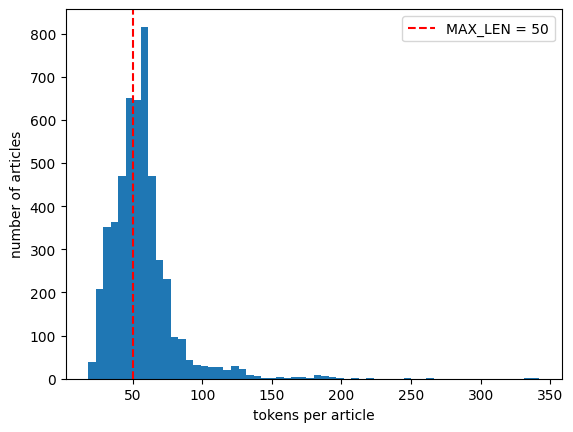

In [44]:
sample_texts = train_data["text"][:5000]

token_ids = tokenizer(sample_texts)["input_ids"]       # TODO: the natural (untruncated) token length of every article in sample_texts
token_lengths = []
more_than_MAX = []

for list_of_ids in token_ids:
    length_of_ids = len(list_of_ids)
    token_lengths.append(length_of_ids)
    
    if length_of_ids > MAX_LEN:
        more_than_MAX.append(length_of_ids)
            
fraction_truncated = len(more_than_MAX)/len(token_lengths)  # TODO: fraction of articles with more than MAX_LEN tokens

print(f"Average length  : {np.mean(token_lengths):.1f} tokens")
print(f"Longest article : {np.max(token_lengths)} tokens")
print(f"Truncated       : {100 * fraction_truncated:.1f}% of the articles are longer than {MAX_LEN} tokens")

plt.hist(token_lengths, bins=60)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.xlabel("tokens per article")
plt.ylabel("number of articles")
plt.legend()
plt.show()

**2.3 Is 50 a reasonable choice?** Roughly half of the articles get cut. Why might that still be fine for *topic* classification, and what is the price of raising `MAX_LEN` to, say, 200?

---

Because we can still classify the topic even if some of the words are truncated. It would be a lot more expensive since small words would need a lot more padding and almost all words would then need padding to reach 200 in length.

---

### DataLoaders

The encoded dataset holds Python lists. Convert them into tensors and wrap them in the same `TensorDataset` / `DataLoader` combination you used in the previous weeks.

**2.4 Complete `to_torch_dataset` and create the two `DataLoader`s.**

Hints:
- `split["input_ids"]` and `split["label"]` are lists — `torch.tensor(..., dtype=torch.long)` turns them into tensors of shape `(n, MAX_LEN)` and `(n,)`. Token ids and class labels both need to be `long` (integer) tensors.
- Shuffle the **training** loader so that every epoch sees the articles in a different order; the test loader does not need shuffling.

In [49]:
BATCH_SIZE = 64

def to_torch_dataset(split):
    inputs = torch.tensor(split["input_ids"], dtype=torch.long)  # TODO: the "input_ids" column as a long tensor of shape (n, MAX_LEN)
    labels = torch.tensor(split["label"], dtype=torch.long)  # TODO: the "label" column as a long tensor of shape (n,)
    return TensorDataset(inputs, labels)


train_dataset = to_torch_dataset(encoded_dataset["train"])
test_dataset = to_torch_dataset(encoded_dataset["test"])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # TODO: DataLoader over train_dataset, batches of BATCH_SIZE, shuffled
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE) # TODO: DataLoader over test_dataset, batches of BATCH_SIZE

In [50]:
# ✅ Check your DataLoaders
X, y = next(iter(train_loader))
print(f"One batch: X {tuple(X.shape)} {X.dtype},  y {tuple(y.shape)} {y.dtype}")

assert X.shape == (BATCH_SIZE, MAX_LEN), f"expected inputs of shape ({BATCH_SIZE}, {MAX_LEN}), got {tuple(X.shape)}"
assert y.shape == (BATCH_SIZE,), f"expected labels of shape ({BATCH_SIZE},), got {tuple(y.shape)}"
assert X.dtype == torch.long and y.dtype == torch.long, "ids and labels must be long tensors"
assert y.min() >= 0 and y.max() <= 3, "labels should be in 0..3"
assert len(train_loader) == 1875 and len(test_loader) == 119, "120,000 / 64 -> 1875 batches, 7,600 / 64 -> 119 batches"
assert train_loader.sampler.__class__.__name__ == "RandomSampler", "the training loader should shuffle"
print("Looks good ✅")

One batch: X (64, 50) torch.int64,  y (64,) torch.int64
Looks good ✅


## 3. The RNN classifier

A recurrent network reads the sequence one token at a time and keeps a **hidden state** $h_t$ that summarises everything it has read so far:

\begin{align}
h_t = \tanh\left(W_{ih}\, x_t + b_{ih} + W_{hh}\, h_{t-1} + b_{hh}\right)
\end{align}

The same weights $W_{ih}$ and $W_{hh}$ are applied at every step. After the last token, $h_T$ is a fixed-size vector that represents the whole article — exactly what a classifier needs.

Our model has three parts:

1. **`nn.Embedding(vocab_size, embed_dim, padding_idx=...)`** — a lookup table that turns each token id into a dense vector. `padding_idx` tells PyTorch that the `[PAD]` id is a placeholder: its embedding is fixed at zero and never trained.
2. **`nn.RNN(embed_dim, hidden_dim, batch_first=True)`** — the recurrence above. With `batch_first=True` it takes input of shape `(B, L, E)` and returns two things:
   - `output`: the hidden state at **every** time step, shape `(B, L, H)`,
   - `hidden`: the hidden state after the **last** time step, shape `(1, B, H)` (the leading 1 is the number of layers).
3. **`nn.Linear(hidden_dim, num_classes)`** — maps the final hidden state to one score (logit) per class.

**3.1 Fill in the three layers and the forward pass.**

Hints:
- The forward pass is: ids → embedding → RNN → take `hidden` → drop its leading dimension with `.squeeze(0)` → linear layer.
- Use `tokenizer.pad_token_id` for `padding_idx`.
- The output are raw logits, no softmax — `nn.CrossEntropyLoss` applies it internally, as it did in Week 2.

In [ ]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = ...  # TODO: nn.Embedding, with padding_idx set to the [PAD] id
        self.rnn = ...        # TODO: nn.RNN with batch_first=True
        self.fc = ...         # TODO: nn.Linear from hidden_dim to num_classes

    def forward(self, x):
        # x: (B, L) token ids
        embedded = ...        # TODO: (B, L, E)
        output, hidden = ...  # TODO: output (B, L, H), hidden (1, B, H)
        logits = ...          # TODO: last hidden state -> (B, num_classes)
        return logits


EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 4

rnn_model = SimpleRNNClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print(rnn_model)

In [ ]:
# ✅ Check your model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

X, y = next(iter(train_loader))
with torch.no_grad():
    logits = rnn_model(X)

assert logits.shape == (BATCH_SIZE, NUM_CLASSES), f"expected logits of shape ({BATCH_SIZE}, {NUM_CLASSES}), got {tuple(logits.shape)}"
assert torch.all(rnn_model.embedding.weight[tokenizer.pad_token_id] == 0), "the [PAD] embedding should be all zeros — did you set padding_idx?"

n_params = count_parameters(rnn_model)
print(f"Trainable parameters: {n_params:,}")
assert n_params == 3_940_356, "expected 3,940,356 parameters: 30,522 x 128 (embedding) + 33,024 (RNN) + 516 (linear)"
print("Looks good ✅")

**3.2 `output` holds the hidden state at every time step, and `hidden` holds the final one — so they must overlap.** Run the RNN on a batch and verify that the **last time step of `output`** is the same tensor as `hidden`.

Hints:
- `output[:, -1, :]` is the last time step for every article in the batch, shape `(B, H)`.
- `hidden[0]` (or `hidden.squeeze(0)`) has the same shape.
- `torch.allclose(a, b)` compares two tensors up to floating-point noise.

In [ ]:
with torch.no_grad():
    embedded = rnn_model.embedding(X)
    output, hidden = rnn_model.rnn(embedded)

print("output:", tuple(output.shape), "  hidden:", tuple(hidden.shape))

last_step = ...  # TODO: the last time step of `output`, shape (B, H)
final_h = ...    # TODO: `hidden` without its leading dimension, shape (B, H)

assert torch.allclose(last_step, final_h), "the last time step of output should equal the final hidden state"
print("Looks good ✅")

**3.3 Think about padding.** The RNN reads all `MAX_LEN` positions — `padding_idx` only makes the `[PAD]` *embedding* zero, it does not skip the step. Suppose we had kept the tokenizer's default and padded on the **right**: for a 20-token article the "final" hidden state would then be computed after 30 more steps of reading zeros. What does the update equation in Section 3 do to $h_t$ during those steps, and why is that a problem for the vanilla RNN in particular? Why does padding on the **left** avoid it? *(Keep your answer in mind when you compare the models in Part 5.)*

---

*Your answer here:*

---

## 4. Training and evaluation

### The metric: F1 per class and macro-F1

Accuracy tells you how many articles were labelled correctly overall. For a **multi-class** problem we also want to know how the model does on *each* class. For a class $c$:

\begin{align}
\text{precision}_c = \frac{TP_c}{TP_c + FP_c}, \qquad
\text{recall}_c = \frac{TP_c}{TP_c + FN_c}, \qquad
F1_c = \frac{2 \cdot \text{precision}_c \cdot \text{recall}_c}{\text{precision}_c + \text{recall}_c}
\end{align}

where $TP_c$ are the articles of class $c$ that were predicted as $c$, $FP_c$ the articles of *other* classes that were wrongly predicted as $c$, and $FN_c$ the articles of class $c$ that were predicted as something else.

**Macro-F1** is the unweighted mean of the four per-class F1 scores — every class counts equally.

**4.1 Implement `compute_f1` with `sklearn.metrics.f1_score`.**

Hints:
- `f1_score(labels, preds, average=None)` returns one F1 score **per class**, as a NumPy array.
- `f1_score(labels, preds, average="macro")` returns their mean.
- The order of the arguments is `(y_true, y_pred)`.

In [ ]:
def compute_f1(labels, preds):
    """Return (F1 per class as an array, macro-F1) for two lists of class ids."""
    f1_per_class = ...  # TODO: one F1 score per class
    macro_f1 = ...      # TODO: their unweighted mean
    return f1_per_class, macro_f1

In [ ]:
# ✅ Check your metric on a toy example you can verify by hand
toy_labels = [0, 0, 1, 1, 2, 3]
toy_preds  = [0, 1, 1, 1, 2, 2]
#   class 0: 1 TP, 0 FP, 1 FN -> precision 1,   recall 0.5 -> F1 0.667
#   class 1: 2 TP, 1 FP, 0 FN -> precision 0.67, recall 1   -> F1 0.8
#   class 2: 1 TP, 1 FP, 0 FN -> precision 0.5,  recall 1   -> F1 0.667
#   class 3: 0 TP, 0 FP, 1 FN ->                            -> F1 0

f1_per_class, macro_f1 = compute_f1(toy_labels, toy_preds)
print("F1 per class:", np.round(f1_per_class, 3), " macro-F1:", round(macro_f1, 3))

assert len(f1_per_class) == 4, "one F1 per class"
assert np.allclose(f1_per_class, [2/3, 0.8, 2/3, 0.0], atol=1e-3), "per-class F1 does not match the hand calculation"
assert np.isclose(macro_f1, np.mean(f1_per_class)), "macro-F1 is the mean of the per-class scores"
print("Looks good ✅")

### Evaluation

**4.2 Complete `evaluate`.** It runs the model over a `DataLoader`, collects the predicted class of every article, and returns the F1 scores.

Remember to:
- put the model in **evaluation mode**,
- run the loop inside **`torch.no_grad()`** — no gradients are needed here,
- move each batch to `device`,
- the predicted class is the one with the **highest logit**: `logits.argmax(dim=1)`.

In [ ]:
def evaluate(model, loader):
    """Return (F1 per class, macro-F1) of `model` on the data in `loader`."""
    ...  # TODO: evaluation mode
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = ...      # TODO: forward pass
            predicted = ...   # TODO: the class with the highest logit, shape (B,)
            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    return compute_f1(all_labels, all_preds)

In [ ]:
# ✅ Check your evaluation on the *untrained* model — it should be at chance level
rnn_model.to(device)
f1_per_class, macro_f1 = evaluate(rnn_model, test_loader)
print("F1 per class:", np.round(f1_per_class, 3), " macro-F1:", round(macro_f1, 3))

assert len(f1_per_class) == NUM_CLASSES
assert 0 <= macro_f1 < 0.45, "an untrained 4-class model should score around 0.25 — something is off"
assert not rnn_model.training, "the model should be left in evaluation mode"
print("Looks good ✅")

### Training

The loop is the same one you wrote in the previous weeks. For every mini-batch:

1. **Forward pass** — token ids in, logits out.
2. **Compute the loss** — `nn.CrossEntropyLoss` between the logits and the labels.
3. **Backward pass** — `zero_grad()`, `backward()`, then **clip the gradients**, then `step()`.

The clipping step is new. Backpropagating through 50 time steps multiplies 50 Jacobians together, and for a vanilla RNN the result occasionally **explodes** into a huge gradient that throws the weights off completely. The standard remedy is **gradient clipping**: if the norm of the gradient exceeds a threshold, it is scaled down to that threshold before the optimizer step. `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)` does this — it is already written for you, and it makes the difference between an RNN that trains and one that does not.

After every epoch we evaluate on the test set and record the numbers in a `history` dict, so we can plot and compare the models later.

**4.3 Fill in the forward pass, the loss, the backward pass and the average loss, then train the RNN in the cell after.**

Hints:
- The backward pass is `zero_grad()` → `backward()` → *(clipping, given)* → `step()`, so it is split around the clipping line.
- `loss.item()` turns the loss tensor into a plain number for logging.
- The average loss of an epoch is the total loss divided by the number of **batches** (`len(train_loader)`).
- We use **Adam** rather than SGD this week. It adapts the step size per parameter and is far less fussy about the learning rate.

> Training the RNN for 3 epochs takes around 3–5 minutes on a CPU. Start it and read ahead to Part 5.

In [ ]:
def train_and_evaluate(model, train_loader, test_loader, num_epochs=3, lr=1e-3):
    """Train `model` with Adam and gradient clipping, evaluating on the test set after every epoch.

    Returns a history dict with one entry per epoch: the average training loss,
    the F1 per class and the macro-F1 on the test set.
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "f1_per_class": [], "macro_f1": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for X, y in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False):
            X, y = X.to(device), y.to(device)

            # TODO: 1. forward pass
            logits = ...

            # TODO: 2. compute the loss
            loss = ...

            # TODO: 3a. zero the gradients and backpropagate
            ...

            # 3b. clip the gradient norm — keeps exploding gradients in check
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # TODO: 3c. update the weights
            ...

            total_loss += loss.item()

        avg_loss = ...  # TODO: average loss per batch in this epoch
        f1_per_class, macro_f1 = evaluate(model, test_loader)

        history["loss"].append(avg_loss)
        history["f1_per_class"].append(f1_per_class)
        history["macro_f1"].append(macro_f1)

        per_class = "  ".join(f"{name} {f1:.3f}" for name, f1 in zip(LABEL_NAMES, f1_per_class))
        print(f"Epoch {epoch + 1}/{num_epochs}  loss {avg_loss:.4f}  |  macro-F1 {macro_f1:.4f}  |  {per_class}")

    return history

In [ ]:
NUM_EPOCHS = 3

torch.manual_seed(0)
rnn_model = SimpleRNNClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
rnn_history = train_and_evaluate(rnn_model, train_loader, test_loader, num_epochs=NUM_EPOCHS)

In [ ]:
# ✅ Check your training
assert len(rnn_history["loss"]) == NUM_EPOCHS and len(rnn_history["macro_f1"]) == NUM_EPOCHS
assert rnn_history["loss"][-1] < rnn_history["loss"][0], "the training loss should go down over the epochs"
assert rnn_history["macro_f1"][-1] > 0.6, "after 3 epochs the RNN should be well above chance (macro-F1 > 0.6)"
print(f"RNN after {NUM_EPOCHS} epochs: macro-F1 {rnn_history['macro_f1'][-1]:.4f}")
print("Looks good ✅")

## 5. LSTM and GRU

The vanilla RNN overwrites its whole hidden state at every step, which makes it hard to *keep* information for many steps and causes gradients to vanish over long sequences. **Gated** architectures fix this by letting the network learn *what to keep and what to overwrite*:

- The **LSTM** (Long Short-Term Memory) adds a separate **cell state** $c_t$ that runs through time with only element-wise operations, and three gates — **forget**, **input** and **output** — that control what is erased from it, written to it, and read from it.
- The **GRU** (Gated Recurrent Unit) is a lighter variant with two gates — **reset** and **update** — and no separate cell state.

Both are drop-in replacements for `nn.RNN` in PyTorch, with one difference in what they return:

- `nn.LSTM(...)(x)` returns `output, (hidden, cell)` — a **tuple** of the final hidden state and the final cell state.
- `nn.GRU(...)(x)` returns `output, hidden`, exactly like `nn.RNN`.

**5.1 Implement `SimpleLSTMClassifier` following the structure of `SimpleRNNClassifier`.** Only the recurrent layer and the unpacking of its output change.

In [ ]:
class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # TODO: embedding, nn.LSTM (batch_first=True) and the linear output layer
        ...

    def forward(self, x):
        # TODO: embedding -> LSTM -> final hidden state -> linear layer
        #       careful: the LSTM returns output, (hidden, cell)
        return ...


lstm_model = SimpleLSTMClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print(lstm_model)

In [ ]:
# ✅ Check your LSTM
with torch.no_grad():
    logits = lstm_model(X)
assert logits.shape == (BATCH_SIZE, NUM_CLASSES), f"expected logits of shape ({BATCH_SIZE}, {NUM_CLASSES}), got {tuple(logits.shape)}"

n_params = count_parameters(lstm_model)
print(f"Trainable parameters: {n_params:,}")
assert n_params == 4_039_428, "expected 4,039,428 parameters — the LSTM layer alone should have 132,096"
print("Looks good ✅")

**5.2 Implement `SimpleGRUClassifier` in the same way.**

In [ ]:
class SimpleGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # TODO: embedding, nn.GRU (batch_first=True) and the linear output layer
        ...

    def forward(self, x):
        # TODO: embedding -> GRU -> final hidden state -> linear layer
        return ...


gru_model = SimpleGRUClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print(gru_model)

In [ ]:
# ✅ Check your GRU
with torch.no_grad():
    logits = gru_model(X)
assert logits.shape == (BATCH_SIZE, NUM_CLASSES), f"expected logits of shape ({BATCH_SIZE}, {NUM_CLASSES}), got {tuple(logits.shape)}"

n_params = count_parameters(gru_model)
print(f"Trainable parameters: {n_params:,}")
assert n_params == 4_006_404, "expected 4,006,404 parameters — the GRU layer alone should have 99,072"
print("Looks good ✅")

**5.3 Compare the parameter counts.** The recurrent layer has 33,024 parameters in the RNN, 132,096 in the LSTM and 99,072 in the GRU — exactly 1×, 4× and 3× the same number. Where do the factors 4 and 3 come from? And why does the total barely change (3.94M → 4.04M) even though the recurrent layer got four times bigger?

---

*Your answer here:*

---

### Train the gated models

**5.4 Run the cell below** — it trains the LSTM and then the GRU with the exact same setup you used for the RNN.

> Each model takes around 4–6 minutes on a CPU. Read ahead to the MCQs in Part 6 while you wait.

In [ ]:
torch.manual_seed(0)
lstm_model = SimpleLSTMClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print("LSTM")
lstm_history = train_and_evaluate(lstm_model, train_loader, test_loader, num_epochs=NUM_EPOCHS)

torch.manual_seed(0)
gru_model = SimpleGRUClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print("\nGRU")
gru_history = train_and_evaluate(gru_model, train_loader, test_loader, num_epochs=NUM_EPOCHS)

### Compare the three models

**5.5 Plot the macro-F1 on the test set after every epoch for all three models in one figure**, and the training loss in a second one.

Use the `1 × 2` grid of subplots that is created for you: macro-F1 on the left, training loss on the right. Label the axes, add a legend, and use the epoch number (starting at 1) on the x-axis.

In [ ]:
histories = {"RNN": rnn_history, "LSTM": lstm_history, "GRU": gru_history}
epochs = range(1, NUM_EPOCHS + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# TODO: for every model, plot its macro-F1 per epoch on axs[0] and its training loss on axs[1]


# TODO: titles, axis labels and legends

plt.tight_layout()
plt.show()

# A table with the final per-class F1 of every model
print(f"{'':<6}" + "".join(f"{name:>10}" for name in LABEL_NAMES) + f"{'macro-F1':>10}")
for name, history in histories.items():
    per_class = "".join(f"{f1:>10.3f}" for f1 in history["f1_per_class"][-1])
    print(f"{name:<6}{per_class}{history['macro_f1'][-1]:>10.3f}")

**5.6 Interpret the results.** Which model does best, and by how much? Is the ordering what you expected from the discussion in 3.3 and Part 5? Which class is hardest for all three models — can you think of why? And is the extra parameters or the gating what makes the difference?

---

*Your answer here:*

---

## 6. MCQ

Answer each question by writing the letter of your choice (A–D) after **Answer:**.

---

### 6.1. Forget gate

Consider an LSTM. If the forget gate value is set close to **0** for many time steps, what will likely happen to the cell state?

A. It will grow unboundedly<br>
B. It will be preserved across time steps<br>
C. It will gradually reset and lose its long-term memory<br>
D. It will force the output gate to remain closed<br>

**Answer:** 

---

### 6.2. GRU vs. LSTM

Which of the following statements correctly describes the difference between the GRU and the LSTM?

A. The GRU merges the input and forget gates into a single update gate, while the LSTM keeps them separate<br>
B. The GRU maintains both a hidden state and a distinct cell state, just like the LSTM<br>
C. The LSTM uses a reset gate to directly control the candidate hidden state, whereas the GRU does not<br>
D. The GRU completely eliminates the use of nonlinear activations in its gating mechanism<br>

**Answer:** 

---

### 6.3. Vanishing gradients

In Backpropagation Through Time (BPTT) for RNNs, which factor is primarily responsible for the vanishing gradient problem?

A. The gradient repeatedly involves products of Jacobians $\frac{\partial h_t}{\partial h_{t-1}}$ of the recurrent transition across many time steps<br>
B. The gradient becomes dominated by the output layer's softmax cross-entropy derivative when the sequence length grows<br>
C. The gradient decays mainly because the bias terms accumulate through the recurrent connections<br>
D. The gradient is suppressed because the input-to-hidden transformation has fewer parameters than the hidden-to-hidden recurrence<br>

**Answer:** 

---

### 6.4. Truncated BPTT

In practice, RNNs are often trained with **truncated BPTT**: the network is unrolled for only a fixed number of time steps (e.g. 20 or 50), the sequence is processed in chunks, and gradients are backpropagated only within these windows. The main reason for doing this is:

A. To avoid overfitting by randomly dropping parts of the sequence<br>
B. To limit the computational cost and mitigate exploding/vanishing gradients over very long sequences<br>
C. To enforce fixed-length sequences as input<br>
D. To increase the parallelism of the recurrent connections<br>

**Answer:** 

---

### 6.5. Long dependencies

You compare an RNN, an LSTM and a GRU on a sequence modelling task with very long dependencies. Which of the following best explains why LSTMs often outperform vanilla RNNs?

A. LSTMs completely eliminate the need for backpropagation through time, avoiding vanishing gradients<br>
B. LSTMs introduce a separate memory cell with gates that regulate the information flow, mitigating vanishing gradients<br>
C. LSTMs use fewer parameters than RNNs, which prevents overfitting on long sequences<br>
D. LSTMs replace nonlinear activations with linear updates, ensuring perfect gradient preservation<br>

**Answer:** 

---

### 6.6. Final hidden state

Our classifier uses the hidden state after the **last** time step. With `batch_first=True`, which expression gives this state for a whole batch, with shape `(B, H)`?

A. `output[:, 0, :]`<br>
B. `output[:, -1, :]`<br>
C. `output.mean(dim=1)`<br>
D. `hidden[:, -1, :]`<br>

**Answer:** 

---